# Evaluating Sternberg Rate Models

Trained across 2/13/26 thru 2/16/26

`# train models
for i in {1..4}
do
    echo "Running iteration $i..."
    python main.py --gpu 0 --gpu_frac 0.20 --n_trials 40000 --mode train \
    --N 400 --P_inh 0.20 --som_N 0 --apply_dale True --gain 1.5 --task sternberg \
    --act sigmoid --loss_fn l2 --decay_taus 4 25 --jitter_onset 5 --jitter_delay 3 \
    --output_dir ~/Documents/renee/
    echo "Iteration $i complete."
done
`

jitter onset 5, delay 3. 40k trials. training delay=10.

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-02-16 16:35:31.805666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-16 16:35:31.830583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-16 16:35:31.854180: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-16 16:35:31.860781: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-16 16:35:31.883974: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


## load models

In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/'

model_names = find_files(model_dir, '*.mat')
print(len(model_names))
print(model_names)

22
['/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_225831.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_16_091509.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213423.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_180201.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_16_062747.mat', '/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_205451.ma

In [4]:
perfs_low = []
perfs_high = []
train_tr = []

for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    perfs_low.append(mat_data["eval_perfs"][0][0])
    perfs_high.append(mat_data["eval_perfs"][0][1])
    train_tr.append(mat_data["tr"][0])
    print(f'Training trials: {mat_data["tr"][0]}')
    print(f'Load 1 perf: {mat_data["eval_perfs"][0][0]}, Load 3 perf: {mat_data["eval_perfs"][0][1]}')
    print(f'Ending p_low: {mat_data["p_low"][0]}')


/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_084724.mat
Training trials: [22501]
Load 1 perf: 0.97, Load 3 perf: 0.81
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_213742.mat
Training trials: [28701]
Load 1 perf: 0.96, Load 3 perf: 0.86
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_13_185831.mat
Training trials: [26601]
Load 1 perf: 0.96, Load 3 perf: 0.93
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_14_225831.mat
Training trials: [39999]
Load 1 perf: 0.67, Load 3 perf: 0.97
Ending p_low: [0.2]
/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_15_002559.mat
Training trials: [21901]
Load 1 perf: 0.96, Load 3 perf: 0.84
Ending p_low: [0.2]
/home/nuttidalab/Documents/renee/sternberg/Task_sternberg_N_400_Jitter_5_3_2026_02_16_091509.mat
Training

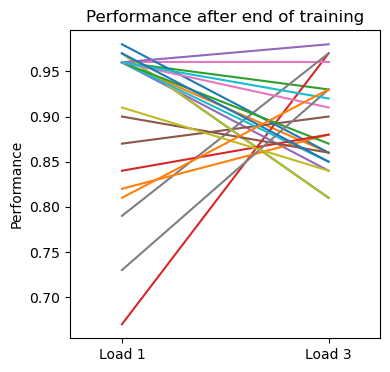

In [5]:
# plot model performances post-training

plt.figure(figsize=(4,4))
plt.plot([perfs_low, perfs_high])
plt.xticks([0, 1], ['Load 1', 'Load 3'])
plt.xlim([-0.25, 1.25])
plt.ylabel('Performance')
plt.title('Performance after end of training')
plt.show()

In [6]:
train_tr = np.array(train_tr)
early_fin = np.where(train_tr < 39999)[0]
print(len(early_fin), len(train_tr))

13 22


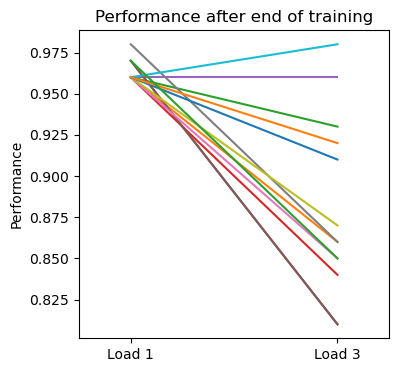

In [7]:
# plot model performances post-training

plt.figure(figsize=(4,4))
for i, model_name in enumerate(model_names):
    if i in early_fin:
        plt.plot([perfs_low[i], perfs_high[i]])
plt.xticks([0, 1], ['Load 1', 'Load 3'])
plt.xlim([-0.25, 1.25])
plt.ylabel('Performance')
plt.title('Performance after end of training')
plt.show()

### model eval

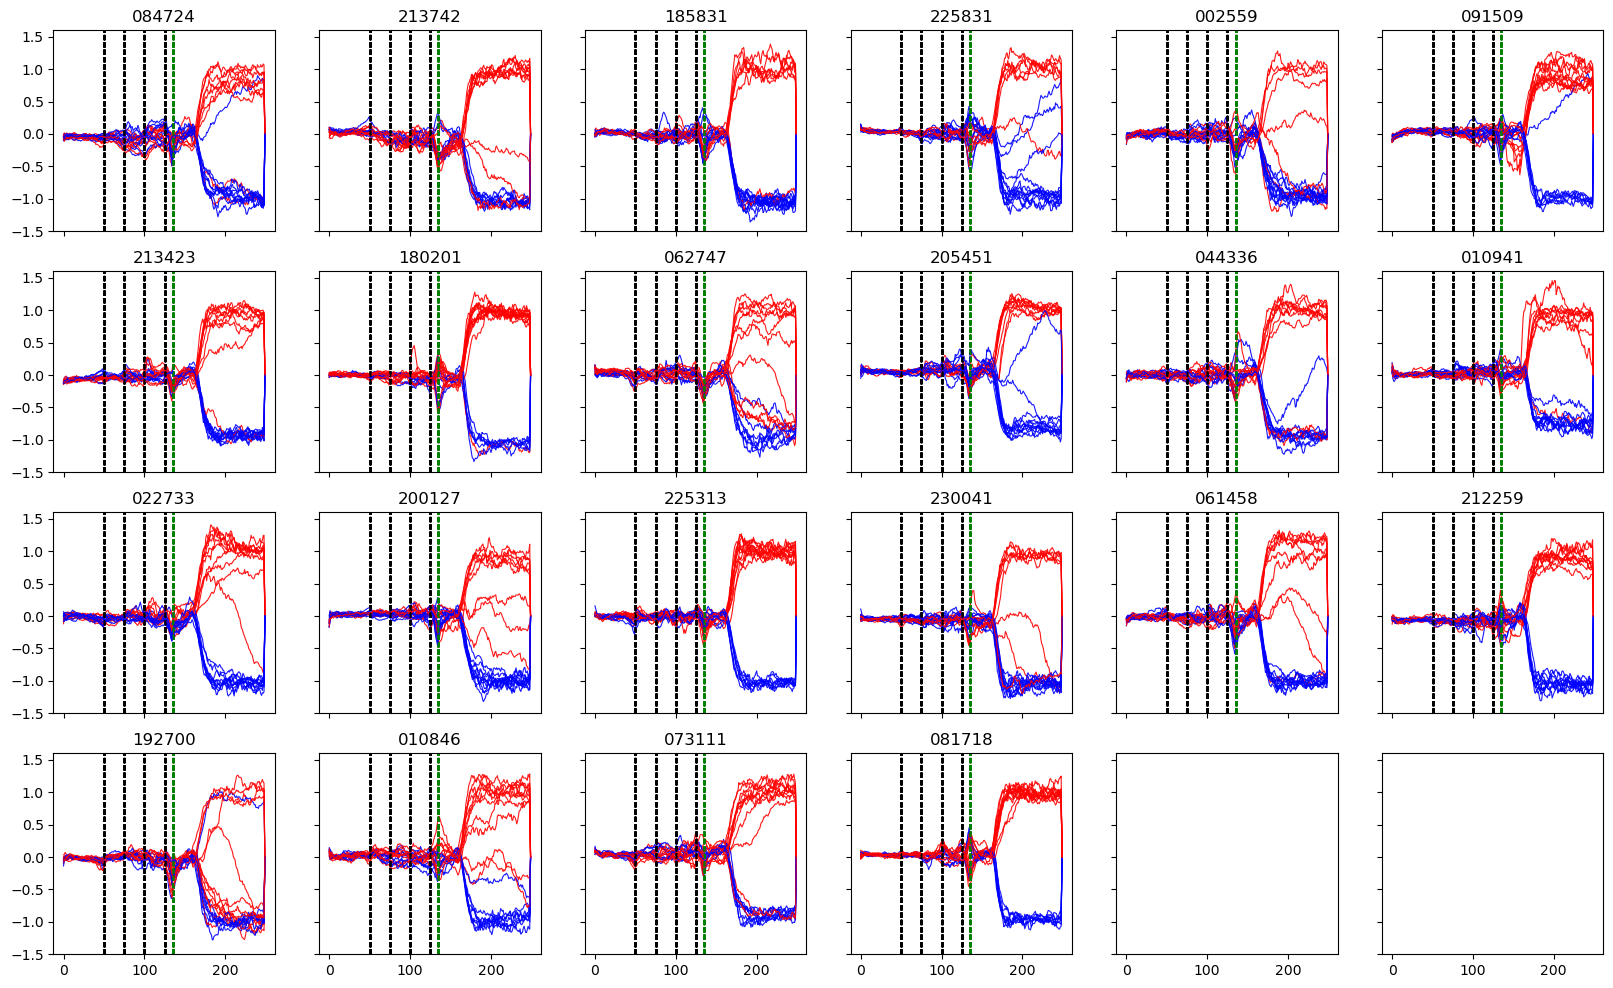

In [15]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + delay, color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}')
plt.show()

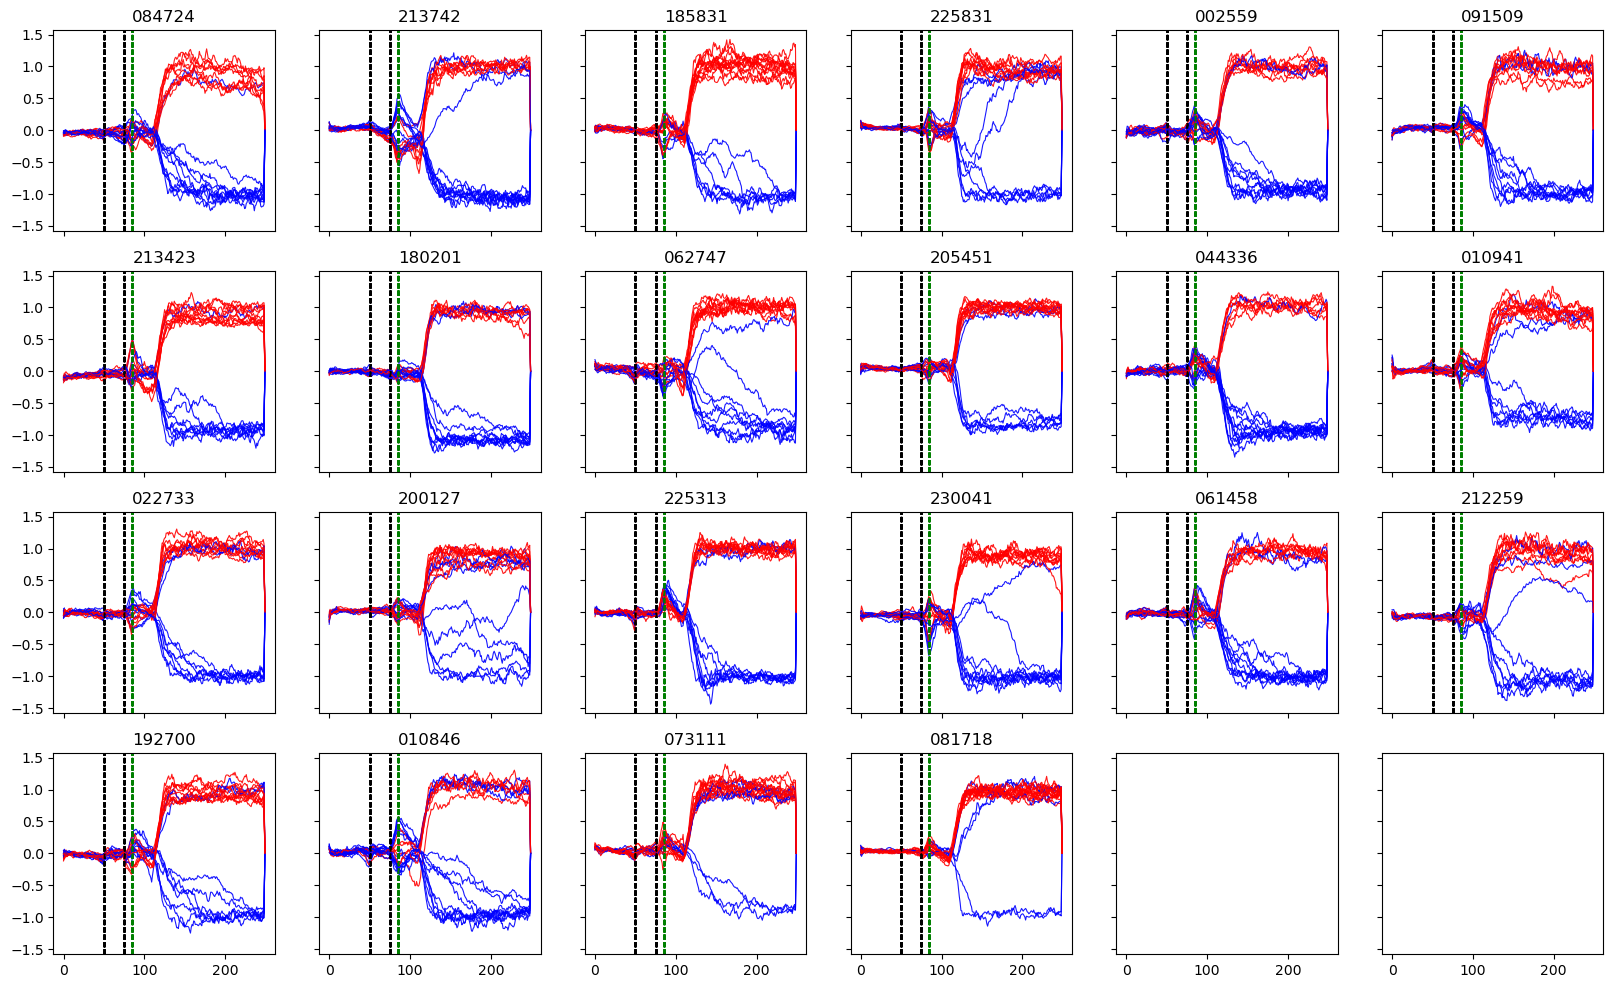

In [16]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + delay, color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}')
plt.show()